# Exercise 1

In [3]:
import numpy as np
from scipy import io
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pylab as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("neural-data-master/02-calcium_imaging/code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

download_data('https://surfdrive.surf.nl/s/uh8XZNenSfuR2fq')

# load image data
dataset = load_digits()
images = dataset.data

# defines a scaler objects
scaler = StandardScaler()
# z-score with fit_transform method
X =scaler.fit_transform(images)

pca = PCA()
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


## Function that outputs number PC given percentage of explained variance

In [3]:
def PCvsEVR(pca, percentage):
    for i in range(len(np.cumsum(pca.explained_variance_ratio_))):
        EVR=np.cumsum(pca.explained_variance_ratio_)[i]
        if EVR >= percentage:
            return i+1 #add 1 because range starts at 0, we need number of PC's

EVRs=[0.33,0.5,0.66,0.9,1]
for p in EVRs:
    print(f"The number of PCs needed for {p*100} percent is {PCvsEVR(pca, p)}")

The number of PCs needed for 33.0 percent is 4
The number of PCs needed for 50.0 percent is 8
The number of PCs needed for 66.0 percent is 13
The number of PCs needed for 90.0 percent is 31
The number of PCs needed for 100 percent is 61


## Structured vs unstructured images

The number of PCs needed for 33.0 percent is 17
The number of PCs needed for 50.0 percent is 28
The number of PCs needed for 66.0 percent is 38
The number of PCs needed for 90.0 percent is 56
The number of PCs needed for 100 percent is 64


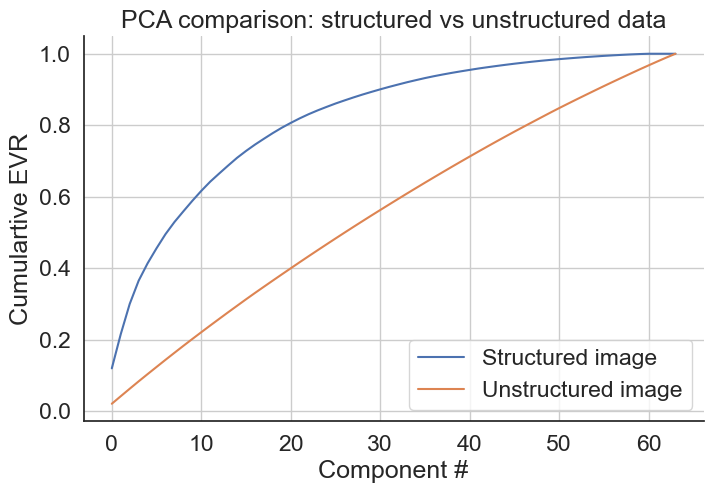

In [4]:
X_random = np.random.permutation(images.flatten()).reshape(images.shape)
pca2=PCA()
pca2.fit(X_random)

for p in EVRs:
    print(f"The number of PCs needed for {p*100} percent is {PCvsEVR(pca2, p)}")

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), label="Structured image")
plt.plot(np.cumsum(pca2.explained_variance_ratio_), label="Unstructured image")

plt.xlabel("Component #")
plt.ylabel("Cumulartive EVR")
plt.title("PCA comparison: structured vs unstructured data")
plt.legend()
plt.grid(True)

plt.show()

> The first thing we notice is that an unstructured (or randomly pixelated) image must have a higher number of PCs for EVR values as compared to a structure (correlated) image. This makes sense since with correlation between pixels, it is easier to see a pattern. The second thing we see is in the curve that the structure image reaces a higher EVR percentage earlier and then slows its increase, while the unstructured image is almost linear. 

# Exercise 2

In [4]:
import pickle

with open('./data/behaviour.pickle', 'rb') as handle:
    trial_data = pickle.load(handle)

voltage_signal = np.load('./data/voltage_signal.npy')
cortex_mask = np.load('./data/cortex_mask.npy')

X2 = voltage_signal.transpose(2,0,1) # reshape in time x image format
T,h,w = X2.shape # saves time, height and width for future use
X2 = X2[:,cortex_mask] # select only cortex pixels, returns a flattened image

pca = PCA(n_components=50);
pca.fit(X2)

/var/folders/zt/1037hy2s1px83v5dgmmdyt680000gn/T/ipykernel_33560/4244130888.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trial_data = pickle.load(handle)


,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


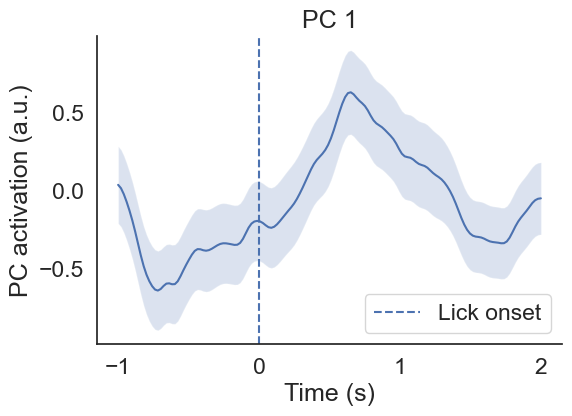

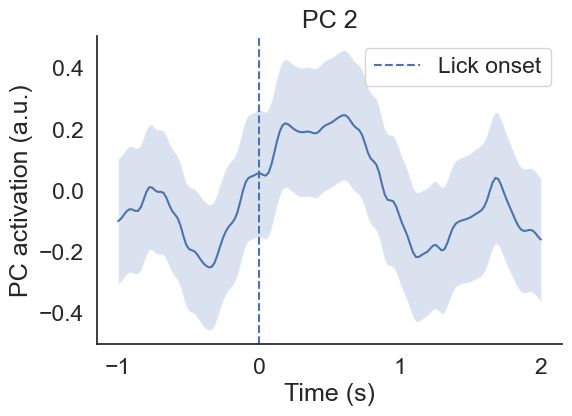

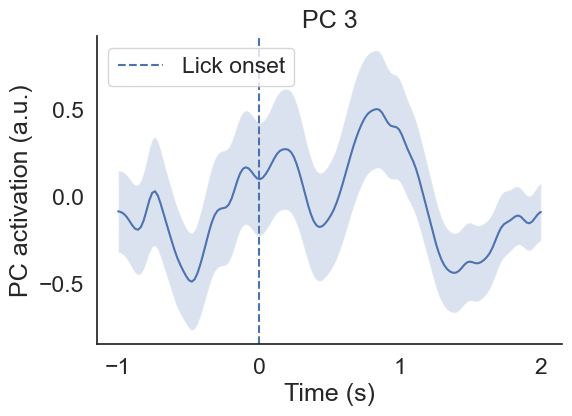

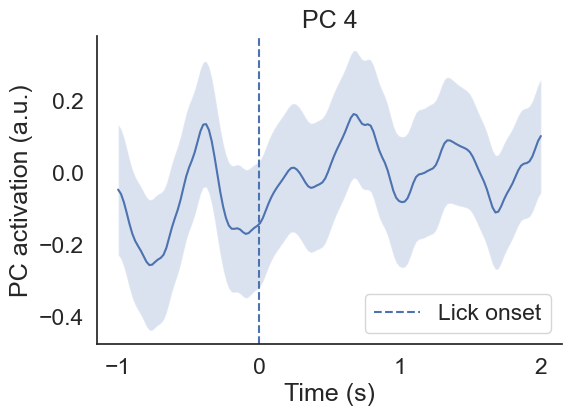

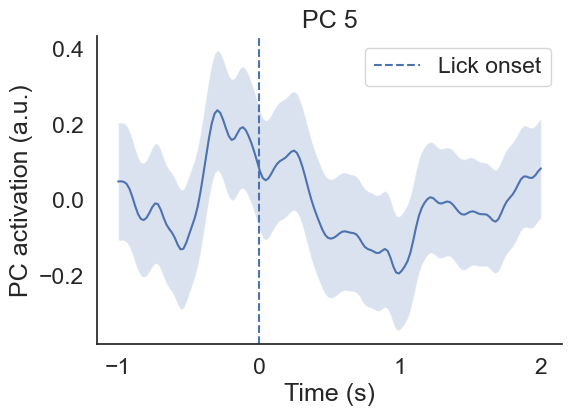

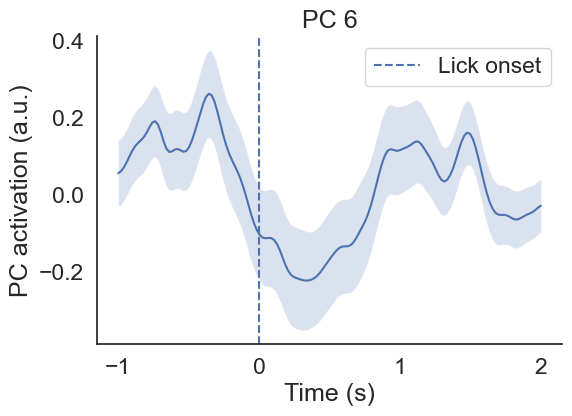

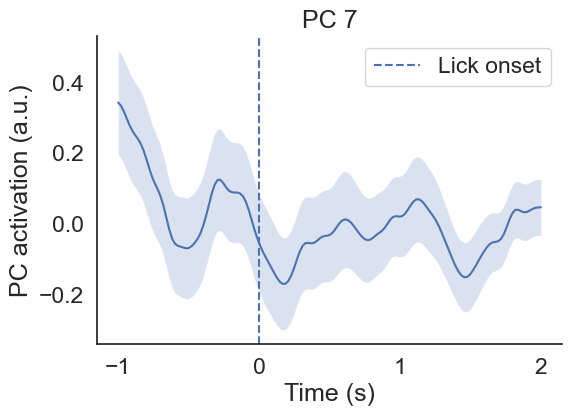

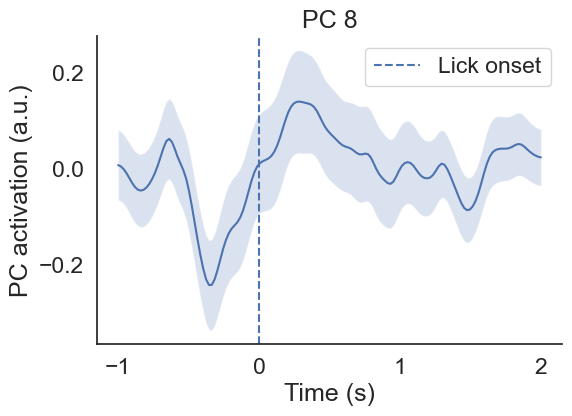

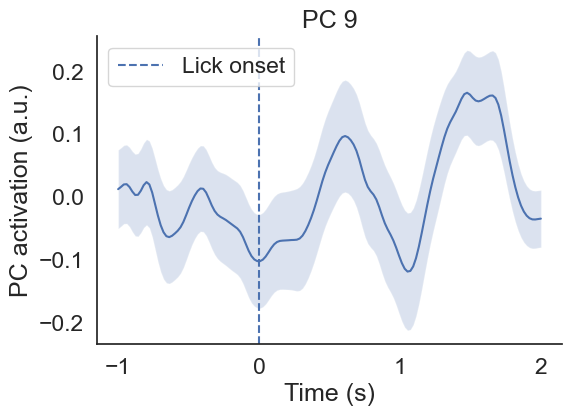

In [19]:
from scipy.stats import sem
from scipy.ndimage import gaussian_filter1d

def component_activation_timecourse(behavioural_event, principal_component, onset_time, offset_time):
    PCs = pca.components_[:10,:].T # select and transpose first 10 PCs weights
    Y = X2 @ PCs # compute the PC timecourse, by projecting the original data on each component
    
    framerate = 50. #in Hz
    start_time = onset_time #seconds
    end_time = offset_time #seconds
    
    frame_times = trial_data['frames'] #frame times
    
    peri_Y = [] #empty list for timecourses
    
    #cycle over onsets
    for i in trial_data[behavioural_event]:
        onset_frame = np.argmin(abs(frame_times-i)) #take frame closest to onset
        start_frame = int(onset_frame + framerate*start_time/1.000) # compute starting frame
        end_frame = int(onset_frame + framerate*end_time/1.000) # compute ending frame
        peri_Y.append(Y[start_frame:end_frame]) #saves the slice of Y
    
    peri_Y = np.asarray(peri_Y) 
    
    mean_Y = np.mean(peri_Y,axis=0) #average over licks
    error = sem(peri_Y,axis=0) #compute sem over licks
    
    comp = principal_component #component to plot
    
    plt.figure(figsize=(6,4))
    t = np.linspace(start_time,end_time,int((end_time-start_time)*framerate))
    y = mean_Y[:,comp-1]
    err = error[:,comp-1]
    
    y = gaussian_filter1d(y,2)
    err = gaussian_filter1d(err,2)
    
    plt.plot(t,y)
    plt.fill_between(t,y-err,y+err,alpha=0.2)

    plt.title(f"PC {comp}")
    plt.xlabel('Time (s)')
    plt.ylabel('PC activation (a.u.)')
    
    plt.axvline(x=0,linestyle='--',label=f"{behavioural_event} onset")
    plt.legend()

for c in range(1,10):
    component_activation_timecourse('Lick', c, -1., 2.)


> We see that not all PCs activate (have a peak) for certain behavioural events. We also see that for Lick events not all PCs respond with a dip to a positive peak. As for positive conditioned stimuli we sometimes see higher oscilations (both positive and negative) after onset. For negative condition stimuli we sometimes see an increase in PC activation after onset. A test for statistical significance is that we should compare the observed result with what would be expected in a statistical null case.

# Exercise 3

## MNIST digit dataset

In [7]:
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap

# load and preprocess data
dataset = load_digits()
images = dataset.data
X = StandardScaler().fit_transform(images)

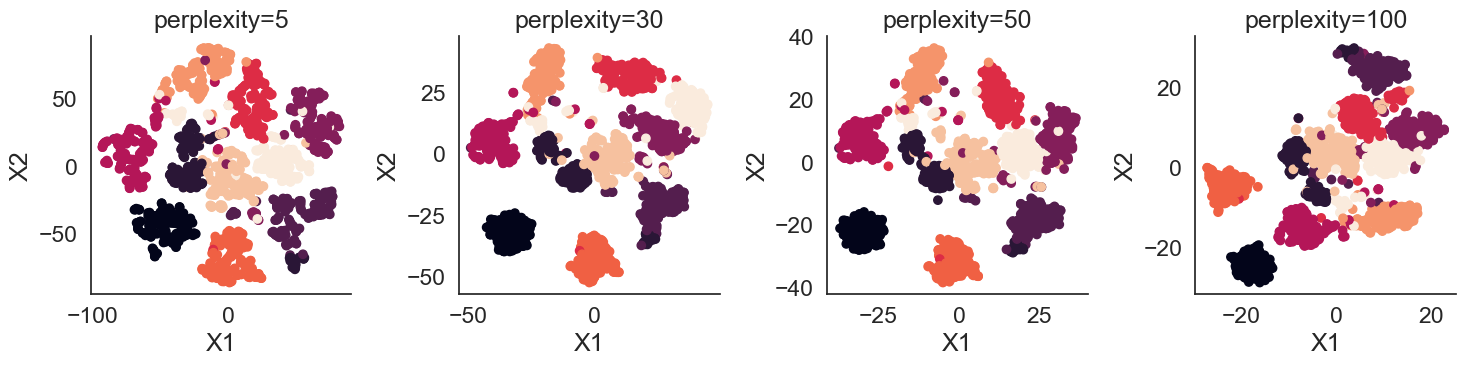

In [8]:
perplexities = [5, 30, 50, 100] #standard is 30

fig, axes = plt.subplots(1, len(perplexities), figsize=(15,4))

for i, px in enumerate(perplexities):
    tsne = TSNE(n_components=2, random_state=0, perplexity=px)
    X_tsne = tsne.fit_transform(X)

    axes[i].scatter(X_tsne[:,0],X_tsne[:,1],c=dataset.target)
    axes[i].set_title(f"perplexity={px}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")

plt.tight_layout()
plt.show()

> A low perplexity gives a very local view. The plots in the middle look the best considering there are clear digit clusters. A high perplexity causes the cluster to blend a bit more.

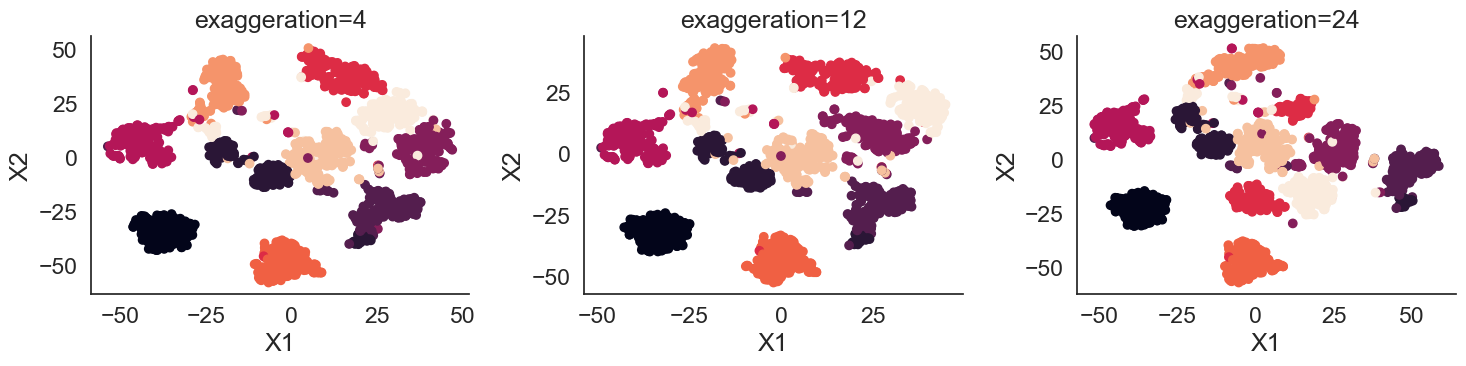

In [9]:
exagerations = [4, 12, 24] #standard is 12.0

fig, axes = plt.subplots(1, len(exagerations), figsize=(15,4))

for i, ex in enumerate(exagerations):
    tsne = TSNE(n_components=2, random_state=0, early_exaggeration=ex)
    X_tsne = tsne.fit_transform(X)

    axes[i].scatter(X_tsne[:,0],X_tsne[:,1],c=dataset.target)
    axes[i].set_title(f"exaggeration={ex}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")

plt.tight_layout()
plt.show()

> We see that a low exaggeration may cause some overlap while a high exaggeration causes the cluster to be far apart. 

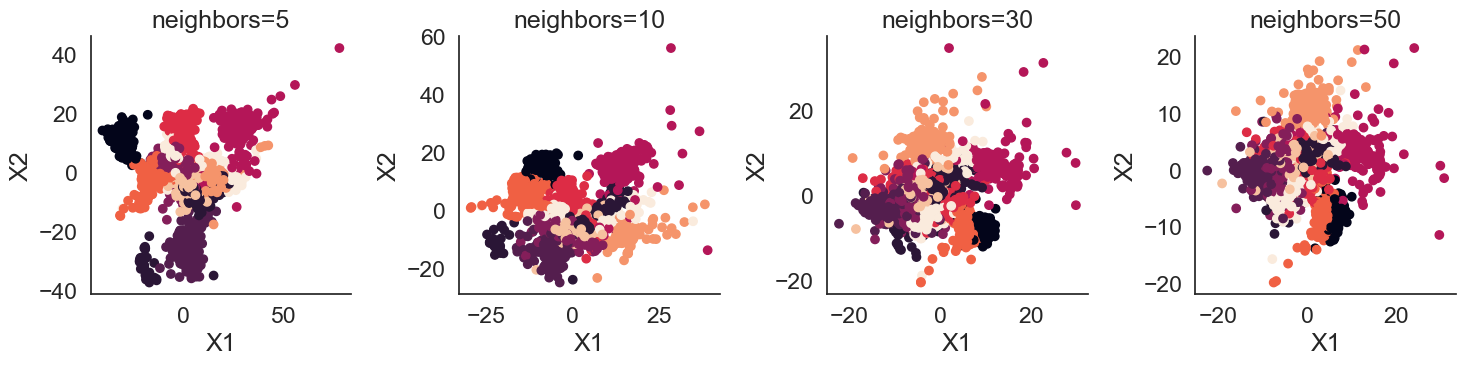

In [10]:
neighbors = [5, 10, 30, 50] #standard is 5

fig, axes = plt.subplots(1, len(neighbors), figsize=(15,4))

for i, n in enumerate(neighbors):
    isomap = Isomap(n_components=2, n_neighbors=n)
    X_iso = isomap.fit_transform(X)

    axes[i].scatter(X_iso[:,0],X_iso[:,1],c=dataset.target)
    axes[i].set_title(f"neighbors={n}")
    axes[i].set_xlabel("X1")
    axes[i].set_ylabel("X2")

plt.tight_layout()
plt.show()    

> Small n neighbors so each point only connects to a few neighbors, this shows in the plot since the colored dots say together. High n neighbors so each point connects to many others, in the plot we see a bigger spread.

## Cortical data

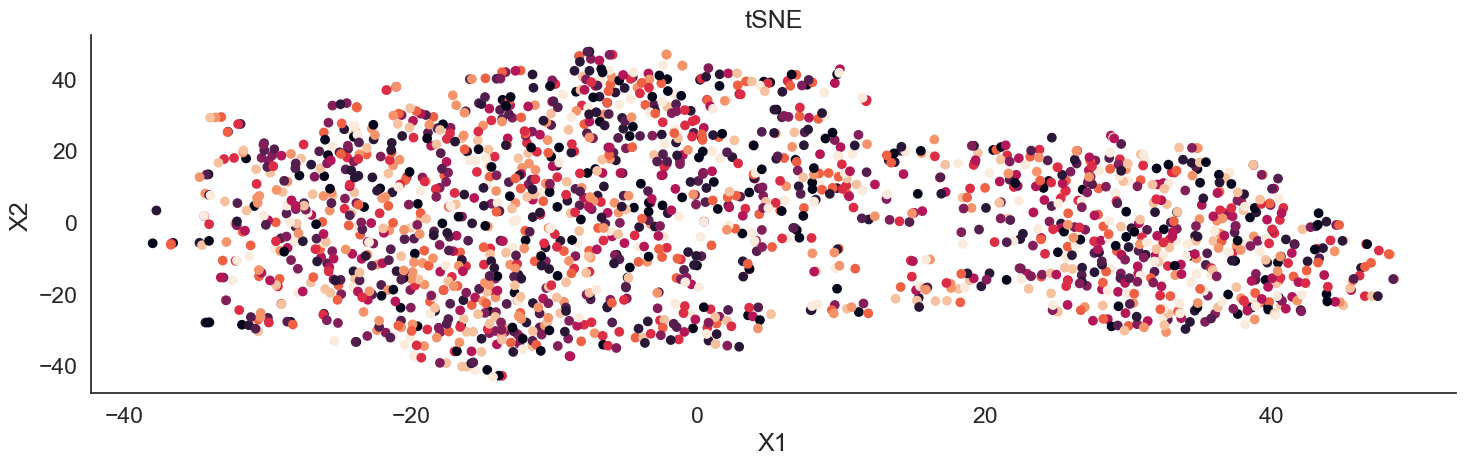

In [18]:
X_small = X2[:1797] #I made it smaller because it kept resetting my kernel
# initialize embedding calculator
tsne = TSNE(n_components=2,random_state=0, perplexity=30, early_exaggeration=12)

#fit emebddings and transform data
X_tsne = tsne.fit_transform(X_small)

plt.figure(figsize=(15,5))
plt.scatter(X_tsne[:,0],X_tsne[:,1],c=dataset.target)
plt.title('tSNE')
plt.xlabel('X1')
plt.ylabel('X2')

plt.tight_layout()

> We see no obvious clusters of colors which makes sense since we are now looking an neural activity which is not very correlated. Even changing the perplexity and exageration did not make them more/less clustered.